In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from os.path import isfile, join
import pylab as plt
from glob import glob
import subprocess
import re
import math

import geopandas
from matplotlib_scalebar.scalebar import ScaleBar

from shapely import wkt

import seaborn as sns
from matplotlib.collections import LineCollection


In [2]:
rawDataDir = "/Users/swise/workspace/takamatsu/data/okazakiDemo/"
procDataDir = "/Users/swise/Projects/hitomi/data/transit/output/"

waterFloodedFile = rawDataDir + "simplifiedWater.shp"
roadsFile = rawDataDir + "simpleRoads_withInundation.shp"
stationsFile = rawDataDir + "trainStationsWithPassengers.shp"


In [3]:
# read in the list of files from the directory
workingDir = procDataDir
files = os.listdir(workingDir)
holder = {} # set up the holder
f = files[0]

In [5]:
scenarios = ["noCommuters", "commuters"]
roadWeights = {}    
for s in scenarios:
    holder[s] = []

# extract them
for f in files:
    isHeatmap = "heatmap" in f
    commutersHere = "noCommuters" not in f
    
    scenarioName = "commuters" if commutersHere else "noCommuters"

    if isHeatmap:
        raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t', header=None)) # read in file
        #raw_data.rename(columns={0: 'road', 1: 'weight'})
        if not scenarioName in roadWeights:
            roadWeights[scenarioName] = raw_data
        else:
            df = roadWeights[scenarioName].merge(raw_data, how='outer', on=0, suffixes=(None, f))
            roadWeights[scenarioName] = df
            
#    else:
        

# fill in empty areas and take the average number of uses
for s in roadWeights:
    df = roadWeights[s]
    df = df.replace(np.NaN, 0)
    df['Mean']= df.iloc[:, 1:].mean(axis=1)
    df['Name']=df[0]
    roadWeights[s] = df

In [6]:
roads = geopandas.read_file(roadsFile)
water = geopandas.read_file(waterFloodedFile)
stations = geopandas.read_file(stationsFile)

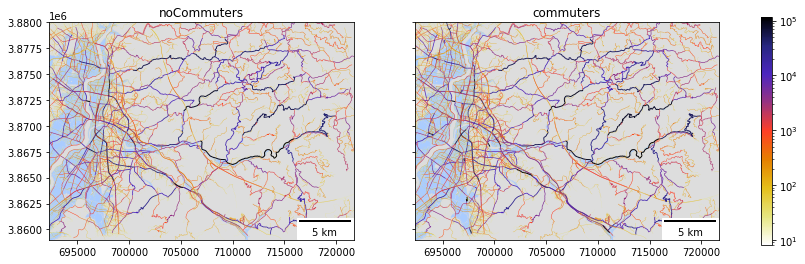

In [7]:
xlim = (692300, 721700)
ylim = (3859000, 3880000)
figureTitle = "Comparison"

# pull out constants to help with plotting
myIndex = 0
numPlots = len(roadWeights)
nrows = int(numPlots / 2)


# set up the correct number of subplots
fig, axs = plt.subplots(ncols=2, nrows = int(numPlots / 2), sharex=True, sharey=True, figsize=(15,6 * nrows + 1))

cmap = plt.cm.get_cmap('CMRmap_r')
#norm = mpl.colors.PowerNorm(2, vmin=0, vmax=150000)#mpl.colors.Normalize(vmin=0, vmax=120000)
norm = mpl.colors.LogNorm(8)

# iterate through the set of settings and plot them separately
for a in roadWeights:

    # select the correct axis upon which to plot
     
    i = myIndex % 2
    j = int(myIndex / 2)

    # just in case there's only the one row and it defaults to a different shape
    if(nrows <= 1):
         ax = axs[i]
    else:
         ax = axs[i, j]


    # plot the background and the people
    
    scenarioRoads = pd.merge(roads, roadWeights[a], left_on="full_id", right_on="Name")
    #scenarioRoads["Mean"] = [max(x, 1) for x in scenarioRoads["Mean"]]
    weights = norm(scenarioRoads["Mean"])
    weights = [max(w, .1) for w in weights]
    colors = cmap(weights)
    
    ax.set_facecolor('#DDDDDD')
    scenarioRoads.plot(ax=ax, linewidth=weights * 5, colors=colors)
    water.plot(ax=ax, color='#AACCFF')
    #b.plot(ax=ax, color='red', alpha=.01, zorder=2)

    # set up the title for this section
    ax.set_title(a)

    # zoom to the interesting part
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
     
    # add a scalebar
    scalebar = ScaleBar(dx=1, location='lower right')
    ax.add_artist(scalebar)

    # update the very hacky index
    myIndex += 1

#fig.subplots_adjust(right=0.8)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs.ravel().tolist(), shrink=.6)

#fig.suptitle(figureTitle)
#plt.show()
figureFilename = "commuterOutput.png"
plt.savefig(figureFilename, format="png", dpi=720)

In [8]:
scenarioRoads = roads
for a in roadWeights:
    scenarioRoads = pd.merge(scenarioRoads, roadWeights[a].loc[:, ["Name", "Mean"]], left_on="full_id", right_on="Name", suffixes=(False, "_" + a))

In [9]:
scenarioRoads["diff"] = scenarioRoads["Mean_commuters"] - scenarioRoads["MeanFalse"]

(array([2.5566e+04, 6.2000e+01, 1.0000e+01, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-50780.6751773 ,   6142.03432624,  63064.74382979, 119987.45333333,
        176910.16283688, 233832.87234043, 290755.58184397, 347678.29134752,
        404601.00085106, 461523.71035461, 518446.41985816]),
 <BarContainer object of 10 artists>)

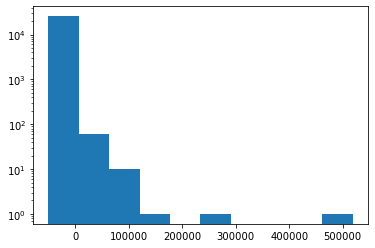

In [10]:
plt.hist(scenarioRoads["diff"], log=True)

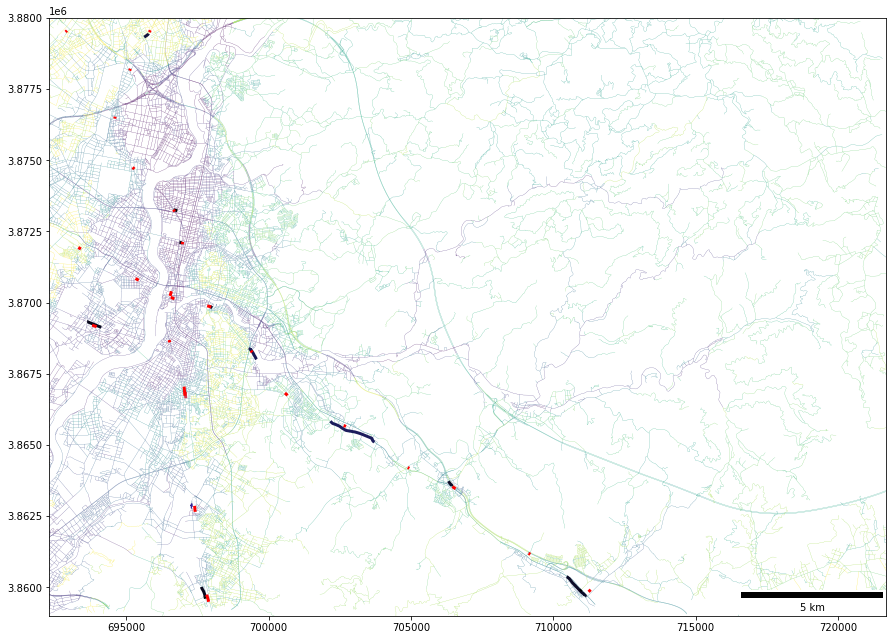

In [11]:
def plotMe():
    xlim = (692300, 721700)
    ylim = (3859000, 3880000)

    #fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(15,12))
    #ax = axs[0]
    ax = scenarioRoads.plot(cmap="viridis", linewidth=.2, figsize=(15,12))
    subset = scenarioRoads[scenarioRoads["diff"] > 50000]
    subset.plot(column="diff", cmap="CMRmap", linewidth=3, ax=ax)
    stations.plot(color="red", ax=ax, linewidth=3)

    # zoom to the interesting part
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
     
    # add a scalebar
    scalebar = ScaleBar(dx=1, location='lower right')
    ax.add_artist(scalebar)
    
    
    figureFilename = "diffOutput.png"
    plt.savefig(figureFilename, format="png", dpi=720)
    
plotMe()

In [13]:
scenarioRoads.head()

,full_id,highway,lanes,oneway,layer,depth,geometry,NameFalse,MeanFalse,Name_commuters,Mean_commuters,diff
0,w117321560,unclassified,None,None,None,6,"LINESTRING (698589.033 3879139.012, 698668.305...",w117321560,17.914894,w117321560,33.200000,15.285106
1,w762920986,motorway,3,yes,1,6,"LINESTRING (697633.245 3879199.060, 697673.451...",w762920986,40.340426,w762920986,75.400000,35.059574
2,w117322127,unclassified,None,None,None,6,"LINESTRING (698413.272 3879231.328, 698460.588...",w117322127,20.851064,w117322127,39.133333,18.282270
3,w128639100,secondary,2,None,1,6,"LINESTRING (698320.335 3879179.740, 698308.072...",w128639100,68.319149,w128639100,100.466667,32.147518
4,w397581438,motorway,3,yes,1,6,"LINESTRING (698759.028 3879818.919, 698470.675...",w397581438,53.574468,w397581438,92.800000,39.225532


In [39]:
# helper function
def extractEvacTime(s):
    bits = s.split(',')
    record = {}
    for b in bits:
        try:
            k,v = b.split(':')
            if k[0] not in record:
                record[k] = float(v)
        except:
            pass

    if "START_EVACUATING" in record:
        startTime = record["START_EVACUATING"]
    else:
        startTime = record["START"]
    finishTime = 1440
    if "FINISH_EVAC" in record:
        finishTime = record["FINISH_EVAC"]
        
    return finishTime - startTime


scenarios = ["noCommuters", "commuters"]
totalPop = {}
evacueeRecord = {}
evacedNums = {}
trappedRecord = {}
localsTrapped = {}
#shelterUsage = {}
for s in scenarios:
    totalPop[s] = []
    evacueeRecord[s] = []
    evacedNums[s] = []
    trappedRecord[s] = []
#    shelterUsage[s] = []
    localsTrapped[s] = []
    
# extract them
for f in files:
    
    if f.startswith("."):
        continue
    
    
    isHeatmap = "heatmap" in f
    commutersHere = "noCommuters" not in f
    
    scenarioName = "commuters" if commutersHere else "noCommuters"

    if isHeatmap:
        continue
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
    totalPop[scenarioName].append(len(raw_data[raw_data["x_home"] < 0]))
    evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
    evac_locals = evacuees[evacuees["x_home"] < 0]
    evacedNums[scenarioName].append(len(evac_locals))
    evacTime = [extractEvacTime(s) for s in evacuees["evacuatingRecord"]]
    evacueeRecord[scenarioName].append(np.mean(evacTime))
    
    trappees = raw_data[raw_data["status"] == "Trapped"].reset_index()
    trappedRecord[scenarioName].append(len(trappees))
    trappees = trappees[trappees["x_home"] < 0]#-10000]
    localsTrapped[scenarioName].append(len(trappees))


204630 people in 90945 households

In [31]:
17398 / 90945.

0.1913024355379625

In [40]:
for s in totalPop:
    print(s, 5 * np.mean(totalPop[s]), 5 * np.std(totalPop[s]))

noCommuters 0.0 0.0
commuters 55643.0 462.93916086961866


In [15]:
scenarios = ["noCommuters", "commuters"]
evacueeFullData = {}

for s in scenarios:
    evacueeFullData[s] = []
    
# extract them
for f in files:
    
    if f.startswith("."):
        continue
    
    
    isHeatmap = "heatmap" in f
    commutersHere = "noCommuters" not in f
    
    scenarioName = "commuters" if commutersHere else "noCommuters"

    if isHeatmap:
        continue
    #elif commutersHere:
    #    continue
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
    evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
    evacTime = [extractEvacTime(s) for s in evacuees["evacuatingRecord"]]
    evacueeFullData[scenarioName].append(evacTime)
    


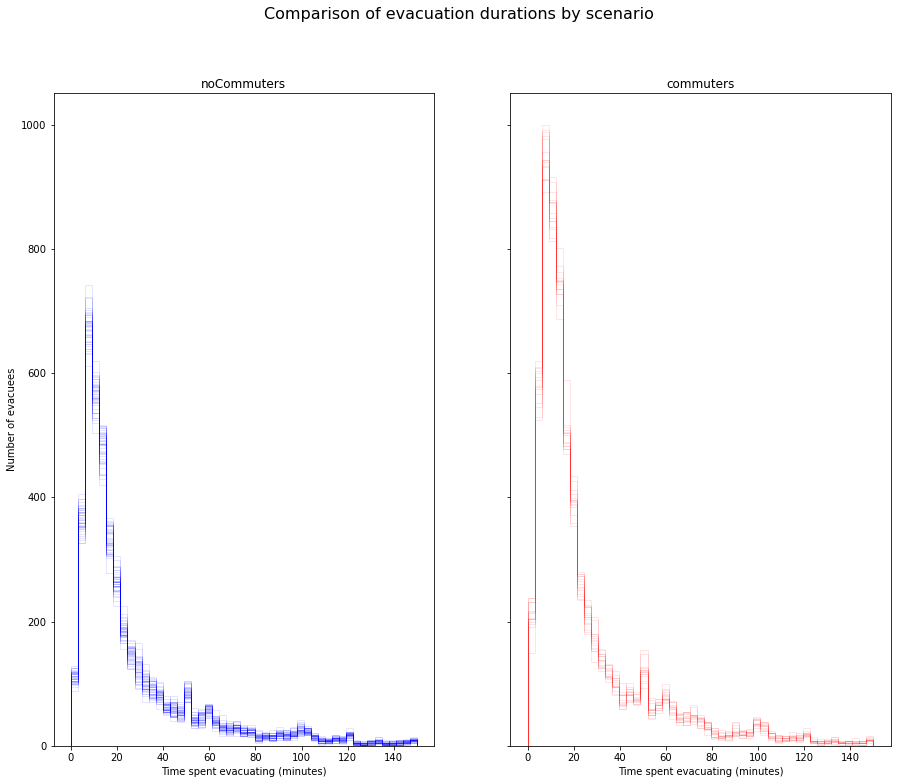

In [16]:
fig, ax = plt.subplots(ncols=len(scenarios), nrows = 1, sharex=True, sharey=True, figsize=(15,12))
bins = np.linspace(0, 150, 50)
axIndex = 0
colDict = {"commuters": "red", "noCommuters": "blue"}

for s in scenarios:
    myAx = ax[axIndex]
    for inst in evacueeFullData[s]:
        myAx.hist(inst, bins, alpha=0.1, label=s, color=colDict[s], histtype='step')
    myAx.set_title(s)
    myAx.set_xlabel("Time spent evacuating (minutes)")
    if axIndex == 0:
        myAx.set_ylabel("Number of evacuees")
#    myAx.hist(evacueeRecord["commuters"], bins, alpha=0.5, label="Commuters")
#    plt.hist(evacueeRecord["noCommuters"], bins, alpha=0.5, label="Locals only")
#    plt.legend(loc='upper right')
    axIndex += 1
plt.suptitle("Comparison of evacuation durations by scenario", fontsize=16)
evacuatingComparisonTimesFilename = "evacuationTimeComparisons.png"
plt.savefig(evacuatingComparisonTimesFilename, format="png", dpi=720)

In [ ]:
ax

In [ ]:

def plotTwoHists(evacueeRecord):
    bins = np.linspace(24, 30, 100)

    plt.hist(evacueeRecord["commuters"], bins, alpha=0.5, label="Commuters")
    plt.hist(evacueeRecord["noCommuters"], bins, alpha=0.5, label="Locals only")
    plt.legend(loc='upper right')
    plt.show()

#evacueeRecord

plotTwoHists(evacueeRecord)


In [ ]:
r = evacueeRecord
for s in r:
    print(s, sum(r[s])/len(r[s]))

In [ ]:
raw_data[raw_data["status"] == "Trapped"]

In [ ]:
# extract them
scenarios = ["commuters", "noCommuters"]

def plotMe():
    xlim = (692300, 721700)
    ylim = (3859000, 3880000)
    colDict = {"commuters": "red", "noCommuters": "yellow"}

    #fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(15,12))
    #ax = axs[0]
    ax = scenarioRoads.plot(color="gray", linewidth=.2, figsize=(15,12))
    stations.plot(color="black", ax=ax, linewidth=3)
    water.plot(ax=ax, color='#AACCFF')

    for f in files:
        if f.startswith("."):
            continue

        isHeatmap = "heatmap" in f
        commutersHere = "noCommuters" not in f

        scenarioName = "commuters" if commutersHere else "noCommuters"

        if isHeatmap:
            continue

        raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
        filts = raw_data[raw_data["status"] == "Trapped"]
        gdf = geopandas.GeoDataFrame(filts, geometry=geopandas.points_from_xy(filts.x_loc, filts.y_loc), crs="EPSG:6690")
        gdf.plot(ax=ax, color=colDict[scenarioName], alpha=.01)
    
    # zoom to the interesting part
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
     
    # add a scalebar
#    scalebar = ScaleBar(dx=1, location='lower right')
#    ax.add_artist(scalebar)
    
    
    figureFilename = "trapeeOutput.png"
    plt.savefig(figureFilename, format="png", dpi=720)
    
plotMe()




NO MAN'S LAND

In [ ]:
def exportMapByScenario(df, figureFilename, figureTitle, waterFilename, roadsFilename, 
                        xcolname = 'x_loc', ycolname = 'y_loc',
                       waterFile = None, includeAtts = {}, excludeAtts = {},
                       xlim = [956000, 974000], ylim = [3805000, 3820000]):
    
    # select on appropriate atts
    defaultFlooding = df
    if len(includeAtts) > 0: # only select if they exist
        defaultFlooding = selectOnAttribute(df, includeAtts, waterFile)
    if len(excludeAtts) > 0: # only select if they exist       
        defaultFlooding = selectOnAttribute(defaultFlooding, selectNonEvacs, exclude=True)
   
    # transform this into spatial data
    gdf = geopandas.GeoDataFrame(defaultFlooding, geometry=geopandas.points_from_xy(
        defaultFlooding[xcolname], defaultFlooding[ycolname]))
    
    # aggregate by the final statuses
    peopleInZone = gdf.groupby(['settings enabled'])#.agg({'ID': 'count'}).reset_index()

    # initialise for the mapping phase
    roads = geopandas.read_file(roadsFilename)
    water = geopandas.read_file(waterFilename)

    # pull out constants to help with plotting
    myIndex = 0
    numPlots = len(peopleInZone)
    nrows = int(numPlots / 2)
    
    # set up the correct number of subplots
    fig, axs = plt.subplots(ncols=2, nrows = int(numPlots / 2), sharex=True, sharey=True, figsize=(15,6 * nrows + 1))

    # iterate through the set of settings and plot them separately
    for a, b in peopleInZone:

        # select the correct axis upon which to plot
        i = myIndex % 2
        j = int(myIndex / 2)

        # just in case there's only the one row and it defaults to a different shape
        if(nrows <= 1):
            ax = axs[i]
        else:
            ax = axs[i, j]


        # plot the background and the people
        roads.plot(ax=ax, edgecolor='#CCCCCC')
        water.plot(ax=ax, color='#AACCFF')
        b.plot(ax=ax, color='red', alpha=.01, zorder=2)

        # set up the title for this section
        ax.set_title(a)

        # zoom to the interesting part
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        
        # add a scalebar
        scalebar = ScaleBar(dx=1, location='lower right')
        ax.add_artist(scalebar)

        # update the very hacky index
        myIndex += 1

    fig.suptitle(figureTitle)

    myFiletype = figureFilename.split('.')[-1]
    if(myFiletype == 'eps'):
        print("WARNING: eps file types don't retain transparency - maybe try png instead?")
    plt.savefig(figureFilename, format=myFiletype, dpi=72)


In [ ]:
raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t', header=None)) # read in file

In [ ]:
###### a function to read in the given files
###
### files - a list of files produced by the simulation, with a header like
###         ID	age	status	evacuatingTime	flooded	x_home	y_home	
###            x_loc	y_loc	dependent	dependentOf	turnedAway
### prefix - a string indicating the tranche of simulation runs
###
### return - a DataFrame containing all of the raw data, with the scenario
###          parameters included as factors
###
def readInFiles(files, prefix):

    holder = {} # set up the holder

    for f in files: # iterate through files

        if f.startswith(myPrefix): # select the target run
            
            print(f)

            baseName = f[len(myPrefix):] # extract the metadata from the filename

            # filenames look like "sweeper_true_true_true_RitsurinDemo-TakamatsuTyphoon16.shp_5.txt"
            nameBits = baseName.split("_")
            
            if nameBits.len()

            # pull out the relevant settings
            #ageEnabled = nameBits[0] == "true"
            #neighboursEnabled = nameBits[1] == "true"
            #helpersEnabled = nameBits[2] == "true"
            #waterShapefile = nameBits[3]
            scenario = nameBits[1]
            seed = int(nameBits[2].rsplit(".")[0]) # the portion before the .txt or .csv

            # now read in the data
            raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file

            # combo categories of status/flood outcome for individuals
            raw_data['final_status'] = raw_data['status'] + "_" + raw_data['flooded']

            # get counts in each
            #df = raw_data.groupby(['final_status']).agg({'ID': 'count', 'status': 'min', 'flooded': 'min'})

            df = raw_data

            # save the settings for these runs
            df['seed'] = seed
            #df['ageEnabled'] = ageEnabled
            #df['neighboursEnabled'] = neighboursEnabled
            #df['helpersEnabled'] = helpersEnabled
            #df['waterShapefile'] = waterShapefile
            df['scenario'] = scenario

            if(len(holder) == 0):
                holder = df
            else:
                holder = holder.append(df)
    return holder
       
    
# set up the working directory and the relevant set of projects
workingDir = procDataDir
myPrefix = "sweep"

# read in the list of files from the directory
files = os.listdir(workingDir)

# read in the simulation data
holder = readInFiles(files, myPrefix)

# update the time for the evacuating ones!!
holder.head() # show how the data now stands

In [ ]:
etime = "evacuatingTime"
holder[etime] = np.where(holder['status']=="Evacuating", 780 - holder[etime], holder[etime])

In [ ]:
##### create a better title for the scenarios (for use with charts)
###
### x - a DataFrame containing columns 'neighboursEnabled', 'helpersEnabled', and 'waterShapefile'
### waterData - a boolean showing whether or not to include the flooding scenario in the name
###
### return - a pandas Series of human-readable names for the associated scenarios
###
def constructName(x, waterData = True):#False):

    # define if the Neighbour setting is activated
    result = "Neighbours" # a hack to make this easier
    if not x['neighboursEnabled']:
        result = "" # if it's off, reset the title to be empty
    elif x['helpersEnabled']: # if it's not off and there's another parameter, + it!
        result += "+\n"

    # define if the Helper setting is activated        
    if x['helpersEnabled']:
        result += "Helpers"

    # if neither was turned on, just call it a "baseline" example
    if len(result) == 0:
        result = "Baseline"

    if waterData:
        # define what the water setting was
        if x['waterShapefile'].endswith('Flooded.shp'):
            result += " - Flood"
        elif x['waterShapefile'].endswith('Typhoon16.shp'):
            result += " - Typhoon 16"
        elif x['waterShapefile'].endswith('emptyFloodingFile.shp'):
            result += " - Tsunami"
        else:
            result += " - Other"
        
    # return the result
    return result

# create more attractive names
settingNames = holder.scenario#holder.apply(constructName, axis=1)

# store them
holder["settings enabled"] = settingNames
holder.head() # show how the data now stands

In [ ]:
tsunamiArea = "/Users/swise/Projects/hitomi/data/tsunami/notionalInundation.shp"

# transform this into spatial data
df = geopandas.read_file(tsunamiArea)
df

In [ ]:
def selectOnAttribute(df, targetValues, waterFile = None, exclude=False):
    
    myDf = df
    
    # select on the flooding scenario?
    if waterFile is not None:
        # pull out the runs on a specific water setting
        myDf = df[df["waterShapefile"] == waterFile]

    # make sure there's actually something to select!
    if len(targetValues) == 0:
        return myDf
        
    # iterate through, selecting on these
    for i, j in targetValues.items():
        
        if exclude:
            myDf = myDf[~myDf[i].isin(j)]
            
        else:
            myDf = myDf[myDf[i].isin(j)]            

    return myDf

def exportCountByScenario(df, attributeToCount, figureFilename = "output.png", figureTitle = "Count By Scenario", 
                          waterFile = None, includeAtts = {}, excludeAtts = {}, aggregate = True, logmyx = False):

    # select on appropriate atts
    defaultFlooding = df
    if len(includeAtts) > 0: # only select if they exist
        defaultFlooding = selectOnAttribute(defaultFlooding, includeAtts, waterFile)
    if len(excludeAtts) > 0: # only select if they exist
        defaultFlooding = selectOnAttribute(defaultFlooding, selectNonEvacs, exclude=True)

    # aggregate by the final statuses
    if aggregate:
        peopleInZone = defaultFlooding.groupby(['seed', 'settings enabled']).agg({'ID': 'count'}).reset_index()
    else:
        peopleInZone = defaultFlooding

    # sizing
    fig = plt.gcf() # extracting the figure information so we can change sizes
    fig.set_size_inches(15, 8) # change the plot size
    sns.set(font_scale=2) # change the font size
    
    # graphs
    sns.boxplot(x=attributeToCount, y='settings enabled', data=peopleInZone)
    sns.stripplot(x=attributeToCount, y='settings enabled', data=peopleInZone, dodge=True, size=5, color='.3')

    if logmyx:
        plt.xscale('log')

    # adjust the layout for better centering
    plt.tight_layout()
    
    # labels
    plt.xlim(left=0)
    plt.xlabel("# people by end of simulation")
    #plt.xlim((0, max(peopleInZone['ID'])))
    plt.ylabel("")
    plt.title(figureTitle)

    # extract figure type from end of file
    myFiletype = figureFilename.split('.')[-1]
    plt.savefig(figureFilename, format=myFiletype, dpi=300)


In [ ]:
pd.unique(holder.status)

In [ ]:
evacs = selectOnAttribute(holder, {'status': ['Work']}, None)
peopleInZone = evacs.groupby(['seed', 'settings enabled']).agg({'ID': 'count'}).reset_index()
peopleInZone.groupby(['settings enabled']).agg({'ID': 'mean'})

In [ ]:
32 / 463

In [ ]:
exportCountByScenario(holder, 'ID', "relativeEvacuationCounts_blah.eps", "Number of Successful Evacuees 1 Hour After Event", None, {'status': ['Evacuated']}, logmyx=False)


In [ ]:
#exportCountByScenario(holder, 'ID', "relativeEvacuationCounts.eps", "Number of Successful Evacuees 1 Hour After Event", None, {'status': ['Evacuated']})
exportCountByScenario(holder, 'ID', "preparing.eps", "Number Still Evacuating 1 Hour After Event", None, {'status': ['TravelToHomeSheltering']})

In [ ]:
def exportMapByScenario(df, figureFilename, figureTitle, waterFilename, roadsFilename, 
                        xcolname = 'x_loc', ycolname = 'y_loc',
                       waterFile = None, includeAtts = {}, excludeAtts = {},
                       xlim = [956000, 974000], ylim = [3805000, 3820000]):
    
    # select on appropriate atts
    defaultFlooding = df
    if len(includeAtts) > 0: # only select if they exist
        defaultFlooding = selectOnAttribute(df, includeAtts, waterFile)
    if len(excludeAtts) > 0: # only select if they exist       
        defaultFlooding = selectOnAttribute(defaultFlooding, selectNonEvacs, exclude=True)
   
    # transform this into spatial data
    gdf = geopandas.GeoDataFrame(defaultFlooding, geometry=geopandas.points_from_xy(
        defaultFlooding[xcolname], defaultFlooding[ycolname]))
    
    # aggregate by the final statuses
    peopleInZone = gdf.groupby(['settings enabled'])#.agg({'ID': 'count'}).reset_index()

    # initialise for the mapping phase
    roads = geopandas.read_file(roadsFilename)
    water = geopandas.read_file(waterFilename)

    # pull out constants to help with plotting
    myIndex = 0
    numPlots = len(peopleInZone)
    nrows = int(numPlots / 2)
    
    # set up the correct number of subplots
    fig, axs = plt.subplots(ncols=2, nrows = int(numPlots / 2), sharex=True, sharey=True, figsize=(15,6 * nrows + 1))

    # iterate through the set of settings and plot them separately
    for a, b in peopleInZone:

        # select the correct axis upon which to plot
        i = myIndex % 2
        j = int(myIndex / 2)

        # just in case there's only the one row and it defaults to a different shape
        if(nrows <= 1):
            ax = axs[i]
        else:
            ax = axs[i, j]


        # plot the background and the people
        roads.plot(ax=ax, edgecolor='#CCCCCC')
        water.plot(ax=ax, color='#AACCFF')
        b.plot(ax=ax, color='red', alpha=.01, zorder=2)

        # set up the title for this section
        ax.set_title(a)

        # zoom to the interesting part
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        
        # add a scalebar
        scalebar = ScaleBar(dx=1, location='lower right')
        ax.add_artist(scalebar)

        # update the very hacky index
        myIndex += 1

    fig.suptitle(figureTitle)

    myFiletype = figureFilename.split('.')[-1]
    if(myFiletype == 'eps'):
        print("WARNING: eps file types don't retain transparency - maybe try png instead?")
    plt.savefig(figureFilename, format=myFiletype, dpi=72)


In [ ]:
sns.set_style('white')

exportMapByScenario(holder, "stillEvacuating_flooded.png", "Unfinished Evacuation Locations", waterFloodedFile, roadsFile, includeAtts ={'status': ['Evacuating']})

In [ ]:
exportMapByScenario(holder, "workingAtEnd.png", "Working Locations", waterFloodedFile, roadsFile, includeAtts ={'status': ['Work']})



In [ ]:
def exportMetricByScenario(df, metric, func, figureFilename = "output.png", figureTitle = "Metric By Scenario", waterFile = None,
                          includeAtts = {}):

    # select on appropriate atts
    defaultFlooding = df
    defaultFlooding = selectOnAttribute(defaultFlooding, includeAtts, waterFile)

    # aggregate by the final statuses
    peopleInZone = defaultFlooding.groupby(['seed', 'settings enabled']).agg({metric: func}).reset_index()

    # sizing
    fig = plt.gcf() # extracting the figure information so we can change sizes
    fig.set_size_inches(15, 8) # change the plot size
    sns.set(font_scale=2) # change the font size
    
    # graphs
    sns.boxplot(x=metric, y='settings enabled', data=peopleInZone)
    sns.stripplot(x=metric, y='settings enabled', data=peopleInZone, dodge=True, size=5, color='.3')

    #plt.xscale('log')

    # adjust the layout for better centering
    plt.tight_layout()
    
    # labels
    plt.xlabel(func + " of " + metric + " by end of simulation")
    #plt.xlim((0, max(peopleInZone['ID'])))
    plt.ylabel("")
    plt.title(figureTitle)
    plt.xlim(left=0)

    # extract figure type from end of file
    myFiletype = figureFilename.split('.')[-1]
    plt.savefig(figureFilename, format=myFiletype, dpi=300)

In [ ]:
exportMetricByScenario(holder, 'evacuatingTime', 'mean', "evacuatingTime.eps", "Time Unsuccessful Evacuees Spent Evacuating", includeAtts = {'status': ['Evacuating']})



In [ ]:
720 / 60.

## After reviewer comments

Ok, some thoughts

The reviewer's main complaints were as follow:

   > Also, Figures 3 and 5 [the box and whisker plots - ed] are hard to interpret and present very little information. Even in its current form, Figure 3 and 5 needs to be explained more and needs a more detailed caption. 

   > It would be better to show how many people are successfully evacuated after each 10ticks (say).

Fair enough! So let's try that latter, and see if it supports my previous conclusions enough for us to go forward with publishing!

The following cells will demonstrate examples of the number of people over time who are **evacuated, attempting to evacuate, or assisting with evacuations**. We track these over the critical one hour post-tsunami period. In particular, we emphasise the difference between the speed of respond in typhoon and storm surge contexts - both in size and speed.

In [ ]:
myColors = [[1, 0, 0, .1], [0, 1, 0, .1], [0, 0, 1, .1], [1, .5, 0, .3], [.5, 0, .5, .3], [0, .5, .5, .3]]


###### a function to read in the given files
###
### files - a list of files produced by the simulation, with a header like
###         ID	age	status	evacuatingTime	flooded	x_home	y_home	
###            x_loc	y_loc	dependent	dependentOf	turnedAway
### prefix - a string indicating the tranche of simulation runs
###
### return - a DataFrame containing all of the raw data, with the scenario
###          parameters included as factors
###
def readInFiles(files, prefix, verbose=False):

    evac_holder = {} # set up the holder
    attempt_holder = {} # set up the holder
    assist_holder = {} # set up the holder

    for f in files: # iterate through files

        if f.startswith(myPrefix): # select the target run
            
            if verbose:
                print(f)
            
            # pull out scenario combination
            rawScenario, seed = f.rstrip(".txt").rsplit("_", 1)

            # now read in the data
            with open(workingDir + f) as ff:
                raw_text = ff.readlines()
                evacuees = [int(x) for x in raw_text[0].rstrip("\n")[1:-1].split(', ')]
                attempts = [int(x) for x in raw_text[1].rstrip("\n")[1:-1].split(', ')]
                assists = [int(x) for x in raw_text[2][1:-1].split(', ')]
            
            if rawScenario in evac_holder:
                evac_holder[rawScenario][seed] = evacuees
                attempt_holder[rawScenario][seed] = attempts
                assist_holder[rawScenario][seed] = assists
            else:
                evac_holder[rawScenario] = {seed: evacuees}
                attempt_holder[rawScenario] = {seed: attempts}
                assist_holder[rawScenario] = {seed: evacuees}
            #holder[f] = total

    return evac_holder, attempt_holder, assist_holder

###### a function to graph the different scenarios, grouped by colour
###
### holder - 
###
### timespan - 
###
def chartScenarios(holder, timespan, verbose=False):
    
    # set up graph
    fig, ax = plt.subplots()

    # the x value is set by the simulation - it runs for an hour, checking at the beginning and end of the period
    x = 10 * np.arange(timespan)
    ax.set_xlim(np.min(x), np.max(x))

    # for each of the scenarios, pull out the values separately and create a LineCollection
    scenarioLines = {}

    colorIndex = 0
    maxVal = 0

    for scenario, data in holder.items():
        if verbose:
            print(data)

        # create the line segments
        segs = [np.column_stack([x, d]) for y, d in data.items()]
        for d in data.values():
            maxVal = max(maxVal, max(d))
        
        # assemble these into a LineCollection
        line_segs = LineCollection(segs, array=x, colors=myColors[colorIndex], label=scenario, linewidths=3)
        
        # increment the colour index
        colorIndex += 1

        # store these by scenario name
        scenarioLines[scenario] = line_segs

    for scenario, lines in scenarioLines.items():
        ax.add_collection(lines)

    # visualise
    ax.legend()
    ax.set_ylim(0, maxVal) # setting it manually because lazy

    plt.show()
    
###### a function to graph the different scenarios, grouped by colour
###
### holder - 
###
### timespan - 
###
def chartScenarioComparison(multiHolders, timespan, verbose=False):
    
    # set up graph
    fig, ax = plt.subplots()

    # the x value is set by the simulation - it runs for an hour, checking at the beginning and end of the period
    x = 10 * np.arange(timespan)
    ax.set_xlim(np.min(x), np.max(x))

    # for each of the scenarios, pull out the values separately and create a LineCollection
    scenarioLines = {}

    colorIndex = 0
    maxVal = 0

    for holder in multiHolders:
        for scenario, data in holder.items():
            segs = [np.column_stack([x, d[:timespan]]) for y, d in data.items()]
            for d in data.values():
                maxVal = max(maxVal, max(d))

            line_segs = LineCollection(segs, array=x, colors=myColors[colorIndex%len(myColors)], label=scenario, linewidths=3)
            colorIndex += 1

            scenarioLines[scenario] = line_segs

    for scenario, lines in scenarioLines.items():
        ax.add_collection(lines)

    # visualise
    ax.legend()
    ax.set_ylim(0, maxVal) # setting it manually because lazy

    plt.show()

### Typhoon example

Read in the typhoon data specifically to see how it works

In [ ]:
# set up the working directory and the relevant set of projects
workingDir = "/Users/swise/Projects/hitomi/data/tsunami/output/"#"/Users/swise/Projects/hitomi/data/elderDemo/output/"
myPrefix = "multiOutputsTyphoon"

# read in the list of files from the directory
evac_files = os.listdir(workingDir)

# read in the simulation data
evac, attempt, assist = readInFiles(evac_files, myPrefix)

# update the time for the evacuating ones!!
#holder # show how the data now stands

Let's try visualising these

In [ ]:
chartScenarios(evac, 19)

In [ ]:
chartScenarios(attempt, 19)

They're fairly indistinguishable, I'd say! "Assist" still has the weird ghost friend that doesn't appear anywhere else - **WHY, FIND IT OUT**

In [ ]:
chartScenarios(assist, 19)

### Tsunami example

In [ ]:
myPrefix = "multiOutputs_"
evac_tsunami, attempt_tsunami, assist_tsunami = readInFiles(evac_files, myPrefix)

In [ ]:
chartScenarioComparison([evac, evac_tsunami], 7)

In [ ]:
chartScenarios(attempt_tsunami, 7)

In [ ]:
chartScenarioComparison([attempt, attempt_tsunami], 7)

In [ ]:
chartScenarioComparison([assist, assist_tsunami], 7)

Some points of annoyance:

* I'm probably measuring the number of people trying to assist in a weird way, and I shouldn't do that. My bad. 
    * **HOWEVER** there is something weird when I try to visualise the assists. It's not in the original files, that I can see? **CHECK THIS FURTHER**


__Notes from working through things__
* the other graphs seem very much the same, which is fine and normal - they're getting places at roughly the same time, and that seems correct. But what happens if I apply this to the other runs?
* ok, having tried that, in the case of the typhoon setting:
    * the number of evacuees and attempts is similar regardless of assistance
    * if assistance is turned on (ie neighbours prompt one another to move), that shows up in the metrics. So that's working for sure!
* comparing the typhoon and tsunami cases, there's very clear differences in how people react - this shows up in both the attempted evacuations, successful evacuations, etc. However, there's very little difference between the neighbour and non-neighbour outputs.
* The big question: DO THESE TRACK between the experiments? I'd say conditionally, yes - the total numbers look good, and when I ran the first set, I didn't break it down further, so I can't really compare beyond that.

And now - what's next?

* confirm with Hitomi that this makes sense
* clean up any of these graphs
* revise paper!!!
* SUBMIT


Conclusion:
* let's submit journal article soon - BY CHRISTMAS
    * focus: tsunami context
    * risk perception in different contexts
    * Hitomi doing review of literature
    * Sarah doing review of ABM specific disaster
* work in 2024: disaster risk reduction
* future work: focus on elderly people, their experiences